<a href="https://colab.research.google.com/github/anastasiiaCher/python-for-DPaV/blob/main/labs/%D0%9B%D0%A03_%D0%9E%D0%B1%D0%B5%D1%81%D0%BF%D0%B5%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Постановка задачи


**Цель работы:** исследование и обработка данных для повышения их качества.

**Краткое описание:** в лабораторной работе приводится поэтапный план изучения и обработки намеренно не предобработанных данных. Необходимо выполнить все этапы плана и оценить результаты преобразований.

# Данные


##### **Описание полей**
 - ```country``` — наименование страны;
 - ```country_code``` — код страны;
 - ```date_added``` — дата размещения вакансии;
 - ```has_expired``` — актуальность вакансии;
 - ```job_board``` — агрегатор вакансий, с которого собраны данные;
 - ```job_description``` — описание вакансии;
 - ```job_title``` — наименование должности;
 - ```job_type``` — вид занятости;
 - ```location``` — метоположение организации;
 - ```organization``` — наименование организации;
 - ```page_url``` — ссылка на страницу с вакансией;
 - ```salary``` — заработная плата;
 - ```sector``` — сфера деятельности;
 - ```uniq_id``` — уникальный идентификатор записи о вакансии.

# Понимание данных

In [1]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns

В датасете есть несколько столбцов, в каждой ячейке которых записано одно и то же значение. Есть столбцы, в которых формат записи значений не стандартизирован. А есть такие, где указана информация, не соответствующая названию столбца.

**Первый этап изучения данных** – понять, какие основные проблемы предстоит решить для каждого из столбцов. Для этого загрузите датасет и выведите случайные несколько строк из него. Постарайтесь понять, что из себя представляют данные в столбцах.

ЗЗагружаем датасет и смотрим несколько случайных строк, чтобы понять, с чем предстоит работать.

In [2]:
df = pd.read_csv('monster_com_job_sample.csv')
print('Размер датасета:', df.shape)
df.sample(5)

Размер датасета: (22000, 14)


,country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
20483,United States of America,US,NaN,No,jobs.monster.com,"Founded in 2003, E4D Technologies is a high-te...",D Software Engineer Job in Dallas,Full Time,"Dallas, TX 75081",Manufacturing - Other,http://jobview.monster.com/3d-software-enginee...,NaN,Experienced (Non-Manager),95e73e08026c1c79199134fde9664dfe
18971,United States of America,US,NaN,No,jobs.monster.com,VibrantCare Rehabilitation is currently lookin...,Physical Therapy Aide Job in Pinole,Full Time,"Pinole, CA 94564",NaN,http://jobview.monster.com/Physical-Therapy-Ai...,NaN,NaN,8a59e48c3194601f438e18a540d9a001
15965,United States of America,US,NaN,No,jobs.monster.com,Company Overview Ocean Spray is a vibrant agri...,Customer Development Manager - Kroger Job in C...,Full Time,"Cincinnati, OH",Food and Beverage Production,http://jobview.monster.com/customer-developmen...,NaN,Experienced (Non-Manager),5da4b7aaaaeb30980c7e381b3720ba8f
18763,United States of America,US,NaN,No,jobs.monster.com,Director of Operations – Beverwyck Retirement ...,Director of Operations - Beverwyck Retirement ...,"Full Time , Employee","Albany, NY",Healthcare Services,http://jobview.monster.com/Director-of-Operati...,NaN,Medical Therapy/Rehab Services General/Other: ...,3c98d4165c8c44432d0fc4ed7629fa5c
11569,United States of America,US,NaN,No,jobs.monster.com,Top Notch Consultants is one of the leading cu...,Business Administration and Marketing Associat...,Full Time Employee,"Charlotte, NC 28217",Telecommunications ServicesAdvertising and PR ...,http://jobview.monster.com/business-administra...,NaN,Business/Strategic Management,3e5e0b47b74751d1a900dd53320a244b


**Задание**

Составьте таблицу, в которой будет содержаться название столбца, тип данных в нем и краткое описание проблем, которые вы заметили при первом взгляде на данные.


Название столбца | Тип данных | Проблемы
--- | --- | ---
`country` | str | Только одно значение - "United States of America", не несёт информации
`country_code` | str | Только одно значение - "US", не несёт информации
`date_added` | float | Почти все значения отсутствуют (NaN)
`has_expired` | str | Только одно значение - "No"
`job_board` | str | Только одно значение - "jobs.monster.com"
`job_description` | str | Иногда попадает в другие столбцы (location, sector и т.д.)
`job_title` | str | Иногда содержит указание на местоположение прямо в названии
`job_type` | str | Много вариантов написания одного и того же значения, есть пропуски
`location` | str | Нестандартизированный формат: разные комбинации города, штата и индекса
`organization` | str | Много пропусков, иногда вместо организации стоит описание из job_description
`page_url` | str | Нет проблем, значения уникальны
`salary` | str/float | Почти всё - NaN; где есть - много форматов записи, нет стандартизации
`sector` | str | Много пропусков; иногда содержит данные из organization или job_description
`uniq_id` | str | Значения уникальны - подходит как идентификатор


### Оценка пустых ячеек в датасете

Выясните, в каких столбцах, строках и в каком количестве отсутствуют данные:
1. С помощью модуля `pandas` составьте таблицу, где каждому названию столбца будет сопоставлено общее количество ячеек и количество пустых ячеек.
2. Подсчитайте количество строк датасета, в которых пустыми являются более 75% ячеек.
3. Визуализируйте число пропусков в датасете с помощью модуля, построив столбчатую диаграмму. Для удобства можно воспользоваться модулем `missingno`.


АА nalysis: считаем пропуски по каждому столбцу и смотрим, есть ли строки, где почти всё пустое. Потом строим график.

                 Всего ячеек  Пустых ячеек  Доля пропусков, %
country                22000             0               0.00
country_code           22000             0               0.00
date_added             22000         21878              99.45
has_expired            22000             0               0.00
job_board              22000             0               0.00
job_description        22000             0               0.00
job_title              22000             0               0.00
job_type               22000          1628               7.40
location               22000             0               0.00
organization           22000          6867              31.21
page_url               22000             0               0.00
salary                 22000         18554              84.34
sector                 22000          5194              23.61
uniq_id                22000             0               0.00

Строк с >75% пустых значений: 0


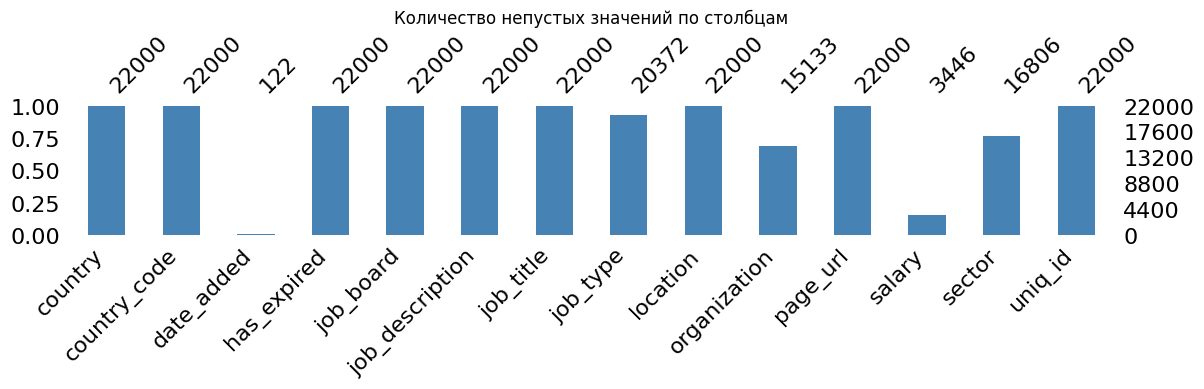

In [3]:
#таблица с количеством пустых ячеек по столбцам
missing = pd.DataFrame({
    'Всего ячеек': len(df),
    'Пустых ячеек': df.isnull().sum(),
    'Доля пропусков, %': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing)

# строки, где больше 75 процентов столбцов пустые
threshold = df.shape[1] * 0.75
rows_mostly_null = (df.isnull().sum(axis=1) > threshold).sum()
print(f'\nСтрок с >75% пустых значений: {rows_mostly_null}')

# визуализация пропусков
msno.bar(df, figsize=(12, 4), color='steelblue')
plt.title('Количество непустых значений по столбцам')
plt.tight_layout()
plt.show()

Проверьте, как изменится размер датасета, если принять решение удалить все строки, где есть пустые значения. Сделайте выводы.

Проверяем, что будет, если удалить все строки с хотя бы одним пропуском

In [4]:
df_clean = df.dropna()
print(f'Размер до удаления строк с пропусками: {df.shape}')
print(f'Размер после удаления: {df_clean.shape}')
print(f'Осталось строк: {len(df_clean)} из {len(df)} ({len(df_clean)/len(df)*100:.1f}%)')
# Вывод: удалять нельзя теряем почти все данные, т.к. salary и date_added почти полностью пустые

Размер до удаления строк с пропусками: (22000, 14)
Размер после удаления: (5, 14)
Осталось строк: 5 из 22000 (0.0%)


### Первичная оценка данных в столбцах

Изучите данные в столбцах датасета, ответив на следующие вопросы:
1. Есть ли столбцы, в которых встречается всего одно значение? Как их можно использовать в анализе?
2. Есть ли такие значения, которые встречаются более чем в одном столбце?
3. Есть ли столбцы, данные в которых не соответствуют названию столбца?

ИИзучаем столбцы: ищем те, где одно значение, смотрим на пересечения значений между столбцами и проверяем соответствие данных названию.

In [17]:
print('Столбцы с одним значением')
for col in df.columns:
    if df[col].nunique() == 1:
        print(f'  {col}: {df[col].unique()[0]!r}')
print('Вывод: country, country_code, job_board, has_expired — одинаковы во всех строках.')
print('Для анализа бесполезны, но можно оставить как метаданные источника.\n')


print('значения которые встреч в нескольких столбцах')

both = df[df['sector'].notna() & df['organization'].notna()]
matches = (both['sector'] == both['organization']).sum()
print(f'Строк, где sector == organization: {matches}')
print('Пример:'); print(df[df['sector'] == df['organization']][['sector','organization']].head(3))

print("\nНесоответствие данных названию столбца")
# location иногда содержит полный текст job_description
long_loc = df['location'].str.len() > 200
print(f'Строк в location длиннее 200 символов (мб job_description): {long_loc.sum()}')
# sector иногда содержит название организации и наоборот
print(f'Строк, где sector == organization: {matches}')

Столбцы с одним значением
  country: 'United States of America'
  country_code: 'US'
  has_expired: 'No'
  job_board: 'jobs.monster.com'
Вывод: country, country_code, job_board, has_expired — одинаковы во всех строках.
Для анализа бесполезны, но можно оставить как метаданные источника.

значения которые встреч в нескольких столбцах
Строк, где sector == organization: 23
Пример:
      sector organization
795   Retail       Retail
1121  Retail       Retail
1810  Retail       Retail

Несоответствие данных названию столбца
Строк в location длиннее 200 символов (мб job_description): 1223
Строк, где sector == organization: 23


### Дублирование данных

Для поиска дублирующихся строк выполните следующие действия:
1. В таблице есть столбец `uniq_id`, значения которого, как сказано в описании данных, являются уникальными идентификаторами записей. Проверьте, действительно ли в этом столбце все значения различны.
2. Проверьте, есть ли в таблице другие столбцы, значения которых в каждой строке различны.
3. Если игнорировать столбцы, где все значения различны, найдутся ли такие строки, для которых значения по всем остальным столбцам будут совпадать?

Оцените результаты поиска дубликатов.

проверяем уникальность uniq_id, ищем другие полностью уникальные столбцы, затем ищем дубликаты по содержательным полям

In [19]:
print('gроверка uniq_id')
print(f'Уникальных значений uniq_id: {df["uniq_id"].nunique()} из {len(df)}')

print('другие столбцы с уникальными значениями')
for col in df.columns:
    if df[col].nunique() == len(df):
        print(f'  {col}')

# 3. Дубликаты, если игнорировать уникальные столбцы
print('\nПоиск дублирующихся строк')
cols_for_dup = [c for c in df.columns if c not in ['uniq_id', 'page_url']]
dup_mask = df.duplicated(subset=cols_for_dup)
print(f'Дублирующихся строк (без учёта uniq_id и page_url): {dup_mask.sum()}')
print('Вывод: дубликаты есть — 1168 строк повторяют другую строку по всем содержательным полям.')

gроверка uniq_id
Уникальных значений uniq_id: 22000 из 22000
другие столбцы с уникальными значениями
  page_url
  uniq_id

Поиск дублирующихся строк
Дублирующихся строк (без учёта uniq_id и page_url): 1168
Вывод: дубликаты есть — 1168 строк повторяют другую строку по всем содержательным полям.


# Практические задания

В этом разделе необходимо обработать значения в трех столбцах датасета: `location`, `salary` и `job_type`. Цель обработки – стандартизировать данные в каждом из столбцов так, чтобы их можно было анализировать.

### Задание 1

В задании 1 необходимо провести обработку столбца `location`.

#### Задание 1.1

В столбце `location` представлена информация о местоположении организации, в которой открыта вакансия. Каждое значение столбца `location` содержит информацию о городе, коде штата и почтовом индексе.

Однако не в каждой строке есть все три характеристики местоположения, а также могут встречаться разные комбинации из них, записанные в виде строки в произвольном порядке и с разными разделителями.

Например, может быть указан только код штата, только название города или только индекс. Могут быть указаны любые две характеристики из трех.

**Формулировка задания:**
1. Определите, какие форматы встречаются.
2. Напишите одно или несколько регулярных выражений для поиска выявленных форматов.
3. Визуализируйте количество найденных форматов на столбчатой или круговой диаграмме. Также покажите на ней количество строк, в которых формат определить не удалось. Какие форматы встречаются чаще всего?

Ознакомиться с теоретическим материалом по работе с регулярными выражениями можно [по ссылке](https://colab.research.google.com/drive/1eFHdmt9OROLEDJRNc2wNmz0gpE1O3sKU?usp=sharing).

определяем форматы, которые встречаются в столбце location, и визуализируем их распределение.

loc_format
City, ST ZIP    11372
City, ST         7169
Не определён     2857
City ZIP          348
ZIP only          254
Name: count, dtype: int64


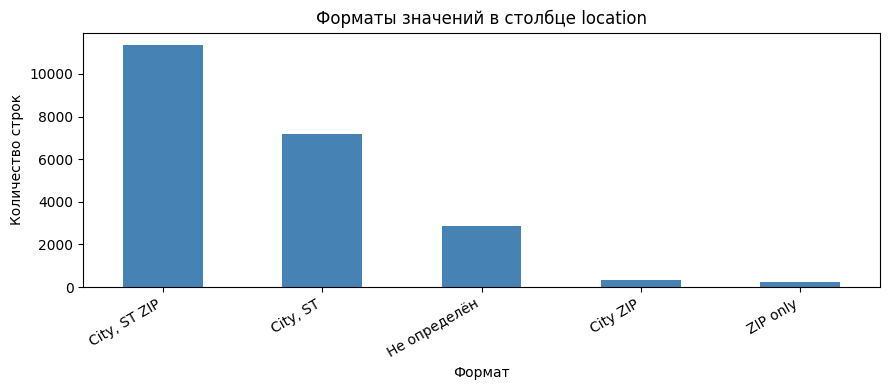

Чаще всего встречается формат City, ST ZIP — город + штат + индекс.


In [20]:
# определяем форматы записи в столбце location
# основные комбинации: город, код штата (2 буквы), почтовый индекс (5 цифр)

patterns = {
    'City, ST ZIP': r'^[A-Za-z\s\.\-]+,\s*[A-Z]{2}\s+\d{5}$',
    'City, ST':     r'^[A-Za-z\s\.\-]+,\s*[A-Z]{2}$',
    'City ZIP':     r'^[A-Za-z\s\.\-]+\s+\d{5}$',
    'ZIP only':     r'^\d{5}$',
    'ST ZIP':       r'^[A-Z]{2}\s+\d{5}$',
    'City ST ZIP':  r'^[A-Za-z\s\.\-]+\s+[A-Z]{2}\s+\d{5}$',
}

loc = df['location'].str.strip()

# определяем формат каждой строки (берём первый подходящий)
def detect_format(val):
    for name, pat in patterns.items():
        if re.match(pat, str(val)):
            return name
    return 'Не определён'

df['loc_format'] = loc.apply(detect_format)
fmt_counts = df['loc_format'].value_counts()
print(fmt_counts)

# визуал
plt.figure(figsize=(9, 4))
fmt_counts.plot(kind='bar', color='steelblue')
plt.title('Форматы значений в столбце location')
plt.xlabel('Формат')
plt.ylabel('Количество строк')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print('Чаще всего встречается формат City, ST ZIP — город + штат + индекс.')

#### Задание 1.2

В большей части строк удалось извлечь данные из ячейки столбца `location`, но остались и такие, где это не получилось. Вынесите в отдельный датасет записи, в которых не удалось определить формат записи информации о местоположении.

Над оставшимися строками проведите следующие преобразования:
1. Данные о местоположении разделите на 3 столбца: город, код штата, почтовый индекс.
2. Так как значения в столбце `почтовый индекс` являются пятизначными числами, преобразуйте их в целочисленный формат.

Разделяем location на три столбца: город, штат, почтовый индекс для строк с известным форматом, остальные откладываем.

In [8]:
# разбив на city, state, zip берём только строки с известным форматом
df_known = df[df['loc_format'] != 'Не определён'].copy()
df_unknown = df[df['loc_format'] == 'Не определён'].copy()
print(f'Строк с известным форматом: {len(df_known)}')
print(f'Строк с неизвестным форматом: {len(df_unknown)}')

def parse_location(row):
    val = str(row['location']).strip()
    fmt = row['loc_format']
    city = state = zipcode = None
    if fmt == 'City, ST ZIP':
        m = re.match(r'^([A-Za-z\s\.\-]+),\s*([A-Z]{2})\s+(\d{5})$', val)
        if m: city, state, zipcode = m.group(1).strip(), m.group(2), int(m.group(3))
    elif fmt == 'City, ST':
        m = re.match(r'^([A-Za-z\s\.\-]+),\s*([A-Z]{2})$', val)
        if m: city, state = m.group(1).strip(), m.group(2)
    elif fmt == 'City ZIP':
        m = re.match(r'^([A-Za-z\s\.\-]+)\s+(\d{5})$', val)
        if m: city, zipcode = m.group(1).strip(), int(m.group(2))
    elif fmt == 'ZIP only':
        m = re.match(r'^(\d{5})$', val)
        if m: zipcode = int(m.group(1))
    elif fmt == 'ST ZIP':
        m = re.match(r'^([A-Z]{2})\s+(\d{5})$', val)
        if m: state, zipcode = m.group(1), int(m.group(2))
    elif fmt == 'City ST ZIP':
        m = re.match(r'^([A-Za-z\s\.\-]+)\s+([A-Z]{2})\s+(\d{5})$', val)
        if m: city, state, zipcode = m.group(1).strip(), m.group(2), int(m.group(3))
    return pd.Series({'city': city, 'state': state, 'zip': zipcode})

df_known[['city', 'state', 'zip']] = df_known.apply(parse_location, axis=1)
df_known['zip'] = df_known['zip'].astype('Int64')  # nullable integer
print(df_known[['location', 'city', 'state', 'zip']].head(5))

Строк с известным форматом: 19143
Строк с неизвестным форматом: 2857
              location             city state    zip
0    Madison, WI 53702          Madison    WI  53702
1    Madison, WI 53708          Madison    WI  53708
3            Dixon, CA            Dixon    CA   <NA>
4         Camphill, PA         Camphill    PA   <NA>
5  Charlottesville, VA  Charlottesville    VA   <NA>


Рассмотрите отложенную часть выборки (ту, где не удалось данные из столбца `location` разделить на три поля) и сделайте выводы о возможности извлечь из данных город, код штата и почтовый индекс. Извлеките все, что возможно. Что невозможно – оставьте пустым.

Разбираем отложенные строки, пытаемся извлечь из них хотя бы код штата или индекс, остальное оставляем пустым

In [21]:
# идея моя крутая: ищем zip (5 цифр), state (2 заглавные буквы), остаток — город

def parse_unknown(val):
    val = str(val).strip()
    # Сначала ищем zip
    zip_m = re.search(r'\b(\d{5})\b', val)
    zipcode = int(zip_m.group(1)) if zip_m else None
    # Ищем код штата это 2 заглавные буквы отдельным словом
    state_m = re.search(r'\b([A-Z]{2})\b', val)
    state = state_m.group(1) if state_m else None
    # если строка слишком длинная (job_description попал) — ничего не извлекаем
    if len(val) > 100:
        return pd.Series({'city': None, 'state': None, 'zip': None})
    # пытаемся выделить город часть до запятой или до штата
    city = None
    city_m = re.match(r'^([A-Za-z\s\.\-]+)', val)
    if city_m:
        city = city_m.group(1).strip() or None
    return pd.Series({'city': city, 'state': state, 'zip': zipcode})

df_unknown[['city', 'state', 'zip']] = df_unknown['location'].apply(parse_unknown)
df_unknown['zip'] = df_unknown['zip'].astype('Int64')

print(f'Извлечён город: {df_unknown["city"].notna().sum()}')
print(f'Извлечён штат: {df_unknown["state"].notna().sum()}')
print(f'Извлечён индекс: {df_unknown["zip"].notna().sum()}')
print()
# Примеры, где вообще ничего нет
all_null = df_unknown[df_unknown[['city','state','zip']].isnull().all(axis=1)]
print(f'Строк, где ничего извлечь не удалось: {len(all_null)}')
print('Примеры:')
print(all_null['location'].head(5).tolist())

Извлечён город: 1580
Извлечён штат: 529
Извлечён индекс: 213

Строк, где ничего извлечь не удалось: 1273
Примеры:
["DePuy Synthes Companies is a member of Johnson & Johnson's Family of Companies, and is recruiting for a Senior Training Leader located in Raynham, MA.DePuy Synthes Companies of Johnson & Johnson is the largest, most innovative and comprehensive orthopedic and neurological business in the world. DePuy Synthes Companies offer an unparalleled breadth and depth of products, services and programs in the areas of joint reconstruction, trauma, spine, sports medicine, neurological, craniomaxillofacial, power tools and biomaterials. Building on the legacy and strengths of two great companies, more agile and better equipped to meet the needs of today’s evolving health care environment. With a focus on activating insights to develop innovative, comprehensive solutions, we are inspired to advance patient care in greater ways than either company could accomplish on its own.Position Ov

### Задание 2

В задании 2 необходимо провести обработку столбца `salary`.

#### Задание 2.1

В столбце `salary`, как и в `location`, данные не стандатизированы. В нем в основном можно встретить записи в следующих форматах:

* 10.00 - 20.00 &dollar; &sol;hour
* 10,000.00 - 20,000.00 &dollar; &sol;year
* &dollar;10.00 &sol;hour
* &dollar;10,000.00+ &sol;year
* Up to &dollar;20,000.00

Основные проблемы, которые стоит учесть при обработке форматов:
- В каждом из форматов может быть или не быть знака доллара.
- Может отсутствовать информация о периоде, за который указывается зарплата (`/hour` или `/year` в примерах).
- Зарплата может быть указана за месяц (`/month`) и за неделю (`/week`).
- В начале, конце и середине некоторых строк есть лишние пробелы, которые не стоит учитывать.

**Задание:**
1. Определите весь перечень встречающихся форматов и напишите одно или несколько регулярных выражений для их поиска.
2. Покажите на столбчатой диаграмме количество записей, содержащих каждый из форматов. Сделайте выводы.

Определяем форматы значений в столбце salary и визуализируем, каких форматов больше всего.

salary
Range + period       2748
Free text             384
Single $ + period     147
Up to $               101
Другое                 57
Range no period         9
Name: count, dtype: int64


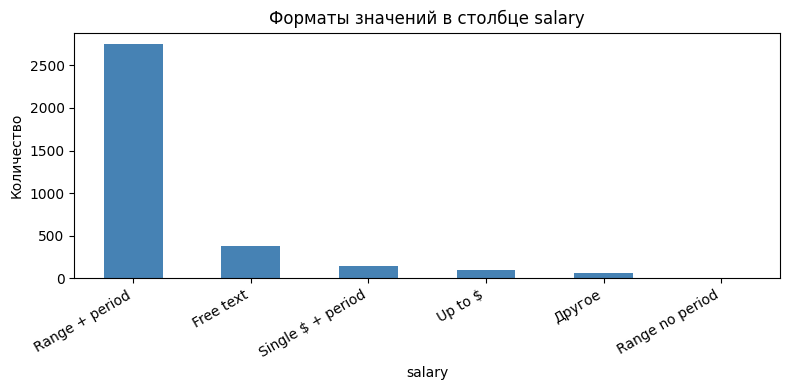

Вывод: чаще всего встречаются диапазоны с указанием периода (hour/year). Значительная часть — свободный текст без числового значения.


In [10]:
sal = df['salary'].dropna().str.strip()

# Определяем форматы зарплаты
sal_patterns = {
    'Range + period':   r'[\d,]+\.?\d*\s*-\s*[\d,]+\.?\d*\s*\$?\s*/\s*(hour|year|month|week)',
    'Single $ + period':r'\$[\d,]+\.?\d*\+?\s*/\s*(hour|year|month|week)',
    'Up to $':          r'[Uu]p\s+to\s+\$[\d,]+\.?\d*',
    'Range no period':  r'[\d,]+\.?\d*\s*-\s*[\d,]+\.?\d*\s*\$',
    'Free text':        r'^[A-Za-z]',
}

def detect_sal_format(val):
    for name, pat in sal_patterns.items():
        if re.search(pat, val):
            return name
    return 'Другое'

sal_fmt = sal.apply(detect_sal_format)
sal_fmt_counts = sal_fmt.value_counts()
print(sal_fmt_counts)

plt.figure(figsize=(8, 4))
sal_fmt_counts.plot(kind='bar', color='steelblue')
plt.title('Форматы значений в столбце salary')
plt.ylabel('Количество')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print('Вывод: чаще всего встречаются диапазоны с указанием периода (hour/year), но значительная часть это свободный текст без числового значения.')

#### Задание 2.2

1. Разделите столбец `salary` зарплаты три: `минимальная граница зарплаты`, `максимальная граница зарплаты`, `период`. Если значение суммы указано только одно, считайте, что это минимальная зарплата. Значение суммы в обоих столбцах преобразуйте в формат `float`.
2. Покажите на столбчатой диаграмме с группировкой среднюю и медианную минимальную зарплату в каждом периоде. Сделайте выводы.

РРазбиваем salary на три столбца: минимальная граница, максимальная граница, период. Строим сравнительный график.

                            salary  sal_min   sal_max sal_period
13            9.00 - 13.00 $ /hour      9.0      13.0       hour
14   80,000.00 - 95,000.00 $ /year  80000.0   95000.0       year
19   60,000.00 - 72,000.00 $ /year  60000.0   72000.0       year
29  70,000.00 - 100,000.00 $ /year  70000.0  100000.0       year
30           62.00 - 81.00 $ /hour     62.0      81.0       hour
32  75,000.00 - 100,000.00 $ /year  75000.0  100000.0       year
36   68,000.00 - 72,000.00 $ /year  68000.0   72000.0       year
41   58,000.00 - 65,000.00 $ /year  58000.0   65000.0       year


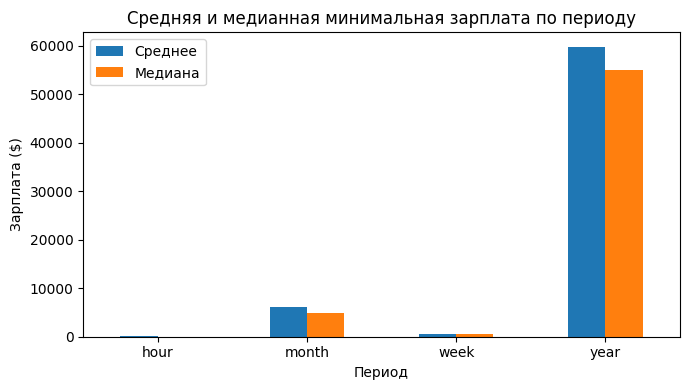

Вывод: годовые зарплаты на порядок выше почасовых (очевидн), медиана ниже среднего, значит есть выбросы сверху


In [23]:
# извлекаем минимум, максимум и период из salary

def parse_salary(val):
    if pd.isna(val):
        return None, None, None
    val = str(val).strip()
    # ищем период
    period_m = re.search(r'/(hour|year|month|week)', val, re.IGNORECASE)
    period = period_m.group(1).lower() if period_m else None
    # Ищем числа (убираем запятые)
    nums = re.findall(r'[\d,]+\.?\d*', val.replace(',', ''))
    nums = [float(n) for n in nums]
    if len(nums) >= 2:
        return nums[0], nums[1], period
    elif len(nums) == 1:
        return nums[0], None, period
    return None, None, period

df[['sal_min', 'sal_max', 'sal_period']] = df['salary'].apply(
    lambda x: pd.Series(parse_salary(x))
)

print(df[['salary', 'sal_min', 'sal_max', 'sal_period']].dropna(subset=['sal_min']).head(8))

# график: средняя и медианная минимальная зарплата по периодам
sal_stats = df.groupby('sal_period')['sal_min'].agg(['mean', 'median']).dropna()
sal_stats.columns = ['Среднее', 'Медиана']
sal_stats.plot(kind='bar', figsize=(7, 4))
plt.title('Средняя и медианная минимальная зарплата по периоду')
plt.xlabel('Период')
plt.ylabel('Зарплата ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print('Вывод: годовые зарплаты на порядок выше почасовых (очевидн), медиана ниже среднего, значит есть выбросы сверху')

#### Задание 2.3

Как было отмечено в задании 2.1, период, за который указывается зарплата, может отсутствовать. Восполните этот пробел в данных следующим образом:

1. Определите диапазон изменения (разброс) значений денежной суммы за каждый из встречающихся в данных периодов. Постройте гистограмму для каждого периода.
2. Определите, к среднему значению за какой период ближе всего сумма, у которой период не указан. Укажите для найденный период. В спорных случаях, где сумма одинаково близка к нескольким диапазонам, не выбирайте ничего.

смотрим диапазоны значений для каждого периода, потом присваиваем период там, где он не указан, ориентируясь на ближайшее среднее.

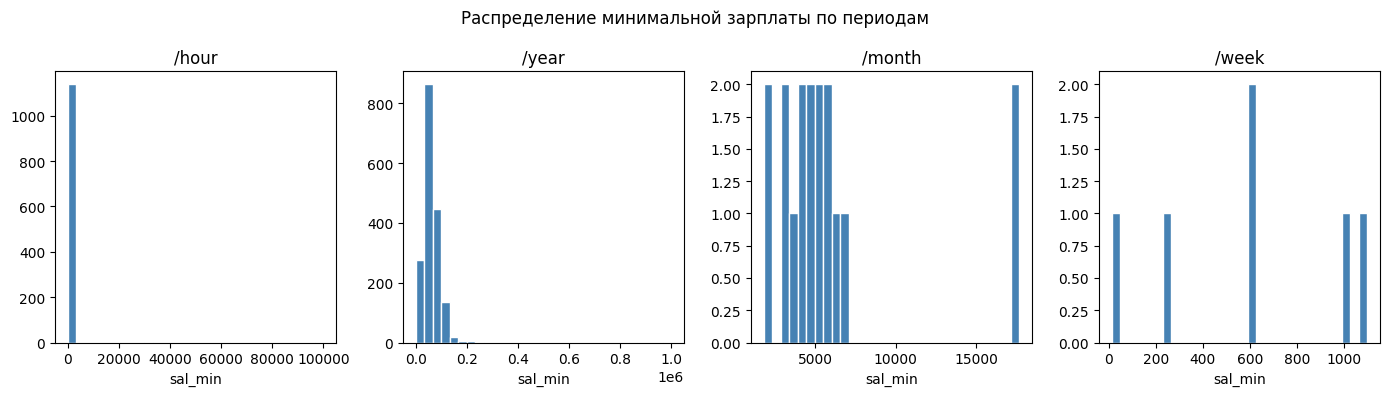

Средняя sal_min по периодам:
sal_period
hour       187.610657
month     6048.408824
week       593.666667
year     59801.385342
Name: sal_min, dtype: float64

Строк без периода, но с суммой: 164
Распределение после заполнения:
sal_period
year     1796
hour     1230
week       31
month      28
Name: count, dtype: int64


In [24]:
# смотрим распределение сумм по периодам и строим гистограммы
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, period in zip(axes, ['hour', 'year', 'month', 'week']):
    subset = df[df['sal_period'] == period]['sal_min'].dropna()
    ax.hist(subset, bins=30, color='steelblue', edgecolor='white')
    ax.set_title(f'/{period}')
    ax.set_xlabel('sal_min')
plt.suptitle('Распределение минимальной зарплаты по периодам')
plt.tight_layout()
plt.show()

# считаем среднее по каждому периоду
period_means = df.groupby('sal_period')['sal_min'].mean()
print('Средняя sal_min по периодам:')
print(period_means)

# дляя строк без периода ищем ближайший период по среднему
no_period = df['sal_period'].isna() & df['sal_min'].notna()
print(f'\nСтрок без периода, но с суммой: {no_period.sum()}')

def assign_period(val):
    diffs = (period_means - val).abs()
    # если минимальное расстояние не единственное (спорный случай) то None
    min_diff = diffs.min()
    candidates = diffs[diffs == min_diff]
    if len(candidates) > 1:
        return None
    return candidates.index[0]

df.loc[no_period, 'sal_period'] = df.loc[no_period, 'sal_min'].apply(assign_period)
print('Распределение после заполнения:')
print(df['sal_period'].value_counts())

### Задание 3

В задании 3 необходимо провести обработку столбца `job_type`. Выясните, какие форматы значений есть в столбце `job_type`. Сделайте выводы. При необходимости – стройте графики.

СС мотрим, какие уникальные значения есть в столбце job_type и насколько они разнообразны.

In [13]:
# смотрим все уникальные значения job_type
print(f'Уникальных значений job_type: {df["job_type"].nunique()}')
print(df['job_type'].value_counts().head(30))

Уникальных значений job_type: 39
job_type
Full Time                                        6757
Full Time Employee                               6617
Full Time, Employee                              3360
Full Time Temporary/Contract/Project             1062
Full Time, Temporary/Contract/Project             533
Full Time , Employee                              406
Part Time Employee                                382
Part Time                                         329
Part Time, Employee                               196
Temporary/Contract/Project                        193
Employee                                          147
Full Time / Employee                              121
Full Time , Temporary/Contract/Project             56
Part Time, Temporary/Contract/Project              34
Per Diem, Employee                                 29
Per Diem                                           22
Job Type Full Time Employee                        19
Part Time Seasonal                      

Вы заметили, что многие значения фактически одинаковые, но немного по-разному отформатированы? Приведем их к единому формату.

Нормализуем форматирование в job_type: убираем лишние пробелы и приводим разделители к единому виду.

In [14]:
# Приводим к единому формату:
# убираем лишние пробелы, нормализуем разделители

df['job_type_clean'] = (
    df['job_type']
    .str.strip()
    .str.replace(r'\s*/\s*', ', ', regex=True)   # '/' → ', '
    .str.replace(r'\s+,\s*', ', ', regex=True)  # ' ,' → ', '
    .str.replace(r',\s+', ', ', regex=True)      # ', ' нормализуем
    .str.replace(r'\s+', ' ', regex=True)        # двойные пробелы
    # убираем мусорный префикс Job Type
    .str.replace(r'^Job Type\s+', '', regex=True)
)

print('После нормализации:')
print(df['job_type_clean'].value_counts().head(20))

После нормализации:
job_type_clean
Full Time                                  6773
Full Time Employee                         6637
Full Time, Employee                        3900
Full Time Temporary, Contract, Project     1064
Full Time, Temporary, Contract, Project     590
Part Time Employee                          384
Part Time                                   330
Part Time, Employee                         202
Temporary, Contract, Project                193
Employee                                    148
Part Time, Temporary, Contract, Project      51
Per Diem, Employee                           29
Per Diem                                     22
Part Time Seasonal                           17
Per Diem Employee                            12
Part Time Temporary, Contract, Project        6
Full Time Intern                              5
Per Diem, Temporary, Contract, Project        4
Part Time Intern                              2
Exempt                                        1
Name:

Столбец `job_type` состоит из двух частей: "полнота" занятости (`Full Time`, `Part Time`, `Per Diem`) и "тип" занятости (`Employee`, `Intern`). Кроме того, встречаются и неполные записи.

Задание:
1. Написать одно или несколько регулярных выражений для разделения столбца `job_type` на два: `полнота занятости`, `тип занятости`.
2. Если данные о полноте отсутствуют, внесите значение `Full Time`.
Если отсутствуют данные о типе – внесите `Employee`.
3. Постройте столбчатую диаграмму со стековой группировкой для полноты и типа занятости. Сделайте выводы.

РРазделяем job_type на два столбца: полнота занятости и тип. Пустые значения заполняем по умолчанию.

Полнота занятости:
job_fullness
Full Time    20940
Part Time      993
Per Diem        67
Name: count, dtype: int64

Тип занятости:
job_emp_type
Employee    21975
Seasonal       17
Intern          8
Name: count, dtype: int64


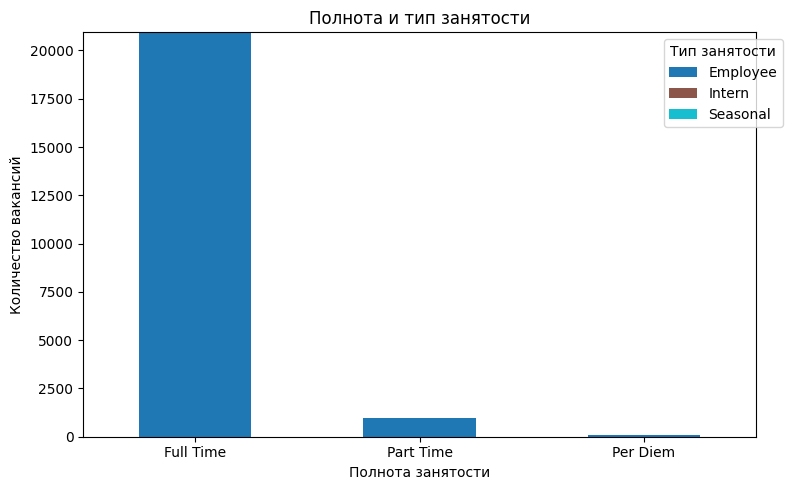

Вывод: подавляющее большинство вакансий — Full Time Employee. Part Time занимает второе место. Intern и Per Diem встречаются редко.


In [15]:
# Разделяем job_type на полноту занятости и тип занятости

fullness_options = ['Full Time', 'Part Time', 'Per Diem']
type_options = ['Employee', 'Intern', 'Temporary/Contract/Project', 'Seasonal']

def extract_fullness(val):
    if pd.isna(val):
        return 'Full Time'
    for opt in fullness_options:
        if re.search(opt, val, re.IGNORECASE):
            return opt
    return 'Full Time'  # по умолчанию

def extract_type(val):
    if pd.isna(val):
        return 'Employee'
    for opt in type_options:
        if re.search(opt, val, re.IGNORECASE):
            return opt
    return 'Employee'  # по умолчанию

df['job_fullness'] = df['job_type_clean'].apply(extract_fullness)
df['job_emp_type'] = df['job_type_clean'].apply(extract_type)

print('Полнота занятости:'); print(df['job_fullness'].value_counts())
print('\nТип занятости:'); print(df['job_emp_type'].value_counts())

# Стековая диаграмма
pivot = df.groupby(['job_fullness', 'job_emp_type']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='tab10')
plt.title('Полнота и тип занятости')
plt.xlabel('Полнота занятости')
plt.ylabel('Количество вакансий')
plt.xticks(rotation=0)
plt.legend(title='Тип занятости', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()
print('Вывод: подавляющее большинство вакансий — Full Time Employee. Part Time занимает второе место. Intern и Per Diem встречаются редко.')

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения всех заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой решение задачи на обработку данных лабораторной работы, меньшее по объему, но сопоставимое по сложности тем заданиям, которые требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. В столбце `sector` часто представлены данные из столбца `organization` и наоборот. Устраните эту проблему.
2. В столбце `job_title` часто можно частично или полностью встретить указание местоположения организации. Сравните, совпадают ли в таких случаях данные с тем, что указано в столбцах `город`, `код штата`, `почтовый индекс`. Если в этих трех столбцах данные отсутствуют, заполните их данными из столбца `job_title`.
3. Практически во всех столбцах датасета вместо соответствующих названию данных иногда встречается текст из `job_description`. Найдите такие столбцы и записи с описанием вакансии в них. Покажите на столбчатой диаграмме, в каких столбцах и в каком количестве находится информация из столбца `job_description`.

# Дополнительные материалы

1. DAMA-DMBOK: Свод знаний по управлению данными: Второе издание / DAMA International; [пер. с англ.]. – Москва: ООО "Олимп-Бизнес", 2021. – 828 с.
2. Макгрегор, С. Обработка данных на Python: Data Wrangling и Data Quality: [Текст] / С. Макгрегор. – Москва: БХВ, 2024. – 432 с.